In [ ]:
# 1. Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import resample
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import spacy
import plotly.express as px
from wordcloud import WordCloud
import joblib
import re

In [ ]:
# 2. Connect to MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['jobs_data']
collection = db['jobs']

In [ ]:
# 3. Load Data
cursor = collection.find({}, {
    'text': 1, 'core_position': 1, 'orgAddress': 1, 'orgCompany': 1, 'name': 1, 
    'dateCreated':1, 'orgTags': 1, 'core_skills': 1, 'contact': 1, 'salary': 1, 'url': 1
}).limit(33000)

data = list(cursor)
df = pd.DataFrame(data)

In [ ]:
# 4. Flatten nested fields
def extract_nested(row, field, subfield):
    try:
        return row[field].get(subfield)
    except:
        return None

# Flatten city and state from orgAddress
df['city'] = df.apply(lambda x: extract_nested(x, 'orgAddress', 'city'), axis=1)
df['state'] = df.apply(lambda x: extract_nested(x, 'orgAddress', 'region'), axis=1)

# Flatten position name from core_position
df['position_name'] = df['core_position']

In [ ]:
# 5. Clean salary
def clean_salary(salary):
    try:
        if isinstance(salary, dict):
            return salary.get('value', None)
        elif isinstance(salary, (int, float)):
            return salary
    except:
        return None
    return None

df['salary_cleaned'] = df['salary'].apply(clean_salary)

In [ ]:
# 6. Normalize and clean core_skills using NLP
nlp = spacy.load('en_core_web_sm')

def clean_skills_with_nlp(skills_list):
    if not isinstance(skills_list, list):
        return []
    cleaned_skills = []
    for skill in skills_list:
        doc = nlp(skill.lower())
        for token in doc:
            if token.pos_ in ['NOUN', 'PROPN']:
                cleaned_skills.append(token.text)
    return cleaned_skills

# Apply cleaning
df['core_skills_nlp_cleaned'] = df['core_skills'].apply(clean_skills_with_nlp)

# Create skills text for vectorization
df['skills_text_cleaned'] = df['core_skills_nlp_cleaned'].apply(lambda x: ' '.join(x))

                                         core_skills  \
0  [Insurance, Commercial Lines, Property & Casua...   
1  [Music Education, Teaching, Lesson Planning, C...   
2  [Guest Service, Product Quality Control, Merch...   
3  [Search Engine Evaluation, Rating Accuracy, Im...   
4  [Grasping, Shrink wrapping, Heat-shrinking, Ba...   
5  [Architecture, Specifications, SpecLink Cloud,...   
6  [AI Training, Data Labeling, Text Analysis, Li...   
7  [Image Processing, Color Correction, Photoshop...   
8  [Scheduling, Cashiering, Dispatching, Customer...   
9  [Piano Performance, Sight Reading, Vocal Coach...   

                                 core_skills_cleaned  
0  [insurance, commercial lines, property & casua...  
1  [music education, teaching, lesson planning, c...  
2  [guest service, product quality control, merch...  
3  [search engine evaluation, rating accuracy, im...  
4  [grasping, shrink wrapping, heat-shrinking, ba...  
5  [architecture, specifications, speclink cloud,... 

In [ ]:
# 7. Map job titles into career categories
def map_job_category(title):
    title = str(title).lower()
    if 'analyst' in title:
        return 'Analyst'
    elif 'engineer' in title or 'developer' in title or 'software' in title:
        return 'Engineer'
    elif 'marketing' in title:
        return 'Marketing'
    elif 'sales' in title:
        return 'Sales'
    elif 'project manager' in title or 'program manager' in title:
        return 'Project Management'
    elif 'customer service' in title or 'help desk' in title or 'support' in title:
        return 'Customer Support'
    elif 'admin' in title or 'administrative' in title or 'receptionist' in title:
        return 'Admin/Clerical'
    elif 'data scientist' in title:
        return 'Data Scientist'
    elif 'manager' in title:
        return 'Management'
    elif 'teacher' in title or 'educator' in title:
        return 'Education'
    else:
        return 'Other'

df['job_category'] = df['name'].apply(map_job_category)

In [ ]:
# Function to infer career level from job title
def infer_career_level(title):
    if not isinstance(title, str):
        return 'OTHER'
    title = title.lower()
    if any(word in title for word in ['intern', 'trainee', 'student']):
        return 'STUDENT'
    elif any(word in title for word in ['junior', 'associate', 'entry level', 'entry-level']):
        return 'JUNIOR'
    elif any(word in title for word in ['senior', 'lead', 'expert']):
        return 'SENIOR'
    elif any(word in title for word in ['manager', 'director', 'head', 'chief']):
        return 'CHIEF'
    else:
        return 'OTHER'

# Apply the function
df['career_level'] = df['position_name'].apply(infer_career_level)

In [ ]:
# Create a final version
df_final = df.copy()

# Save it
df_final.to_pickle('final_df.pkl')

df_final['city'].value_counts().head(20)

city
New York        459
Houston         403
Dallas          359
                331
Atlanta         327
Chicago         315
Austin          307
Boston          301
Phoenix         280
Minneapolis     260
Albuquerque     254
Columbus        249
Los Angeles     232
Seattle         226
Charlotte       223
Portland        219
Raleigh         215
Denver          215
Indianapolis    206
Hartford        205
Name: count, dtype: int64

In [ ]:
# Create Combined Text for Better Features

# Make sure 'skills_text_cleaned' and 'position_name' are combined
df_final['combined_text'] = (
    df_final['skills_text_cleaned'].fillna('') + " " + df_final['position_name'].fillna('')
)

print("Combined text feature created successfully.")

Combined text feature created successfully.


In [ ]:
# 1. Balancing Dataset
X_text = df_final['combined_text'].fillna('')
y_labels = df_final['job_category']

df_model = pd.DataFrame(X_text)
df_model['job_category'] = y_labels

major_class = df_model[df_model['job_category'] == 'Other']
minor_classes = df_model[df_model['job_category'] != 'Other']

minor_upsampled = resample(minor_classes, replace=True, n_samples=len(major_class), random_state=42)
other_downsampled = resample(major_class, replace=False, n_samples=2000, random_state=42)

df_balanced = pd.concat([minor_upsampled, other_downsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# 2. TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_balanced['combined_text'])
y = df_balanced['job_category']

In [ ]:
# 3. Encode Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

c:\Users\akash\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning:

[13:39:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.





Classification Report (XGBoost):
                    precision    recall  f1-score   support

    Admin/Clerical       0.96      0.98      0.97       368
           Analyst       0.96      0.98      0.97       324
  Customer Support       0.96      0.97      0.96       329
    Data Scientist       1.00      1.00      1.00        18
         Education       0.99      0.97      0.98       155
          Engineer       0.99      0.99      0.99      1100
        Management       0.96      0.98      0.97      1063
         Marketing       0.94      0.89      0.92        74
             Other       0.92      0.85      0.89       431
Project Management       0.99      0.96      0.97       167
             Sales       0.98      0.99      0.99       951

          accuracy                           0.97      4980
         macro avg       0.97      0.96      0.96      4980
      weighted avg       0.97      0.97      0.97      4980



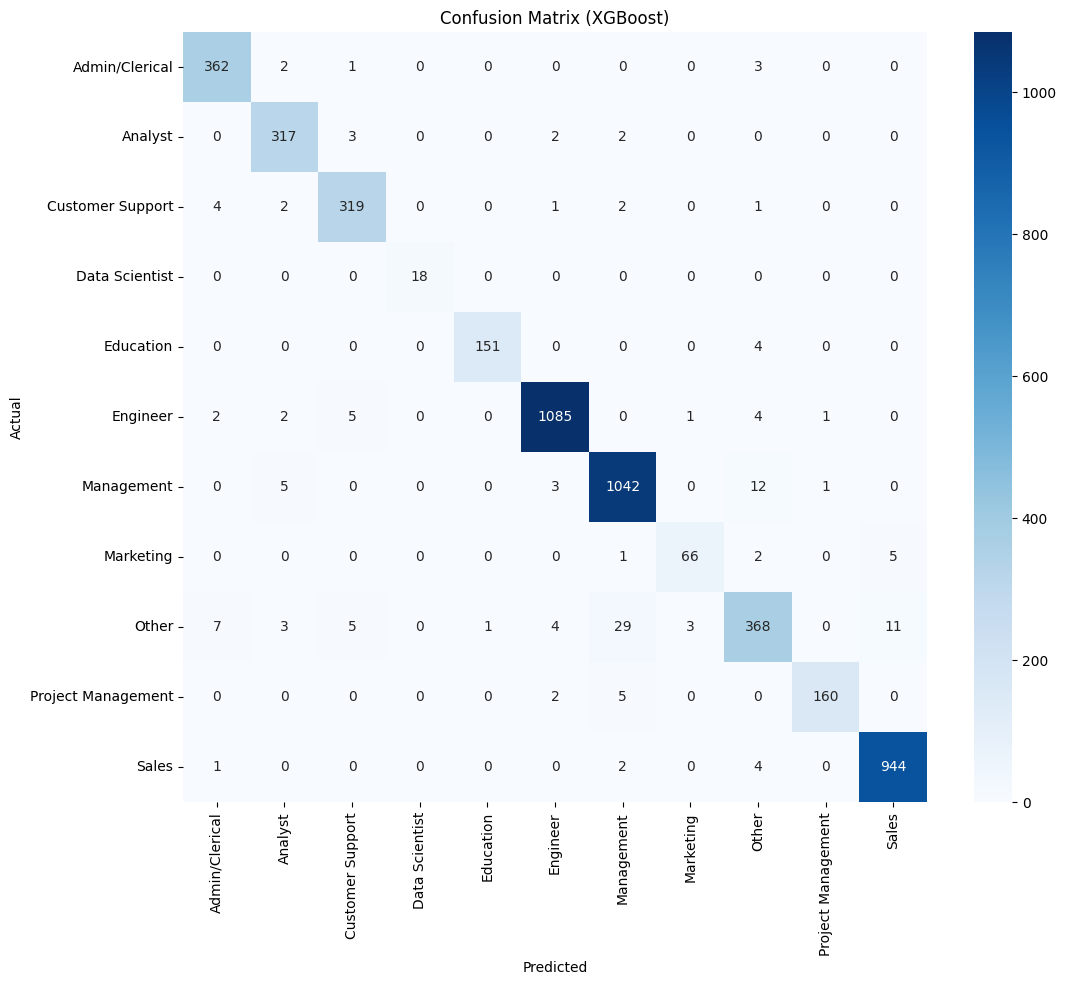

Final model, vectorizer, and label encoder saved successfully.


In [ ]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 5. Train XGBoost Model
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=300,
    max_depth=15,
    learning_rate=0.1,
    random_state=42
)

xgb_classifier.fit(X_train, y_train)

In [ ]:
# 6. Predictions
y_pred = xgb_classifier.predict(X_test)

# 7. Decode Predictions
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

# 8. Evaluate
print("\nClassification Report (XGBoost):")
print(classification_report(y_test_labels, y_pred_labels))

# 9. Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder.classes_)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (XGBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# 10. Save Model, Vectorizer and Label Encoder
joblib.dump(xgb_classifier, 'final_xgboost_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("Final model, vectorizer, and label encoder saved successfully.")

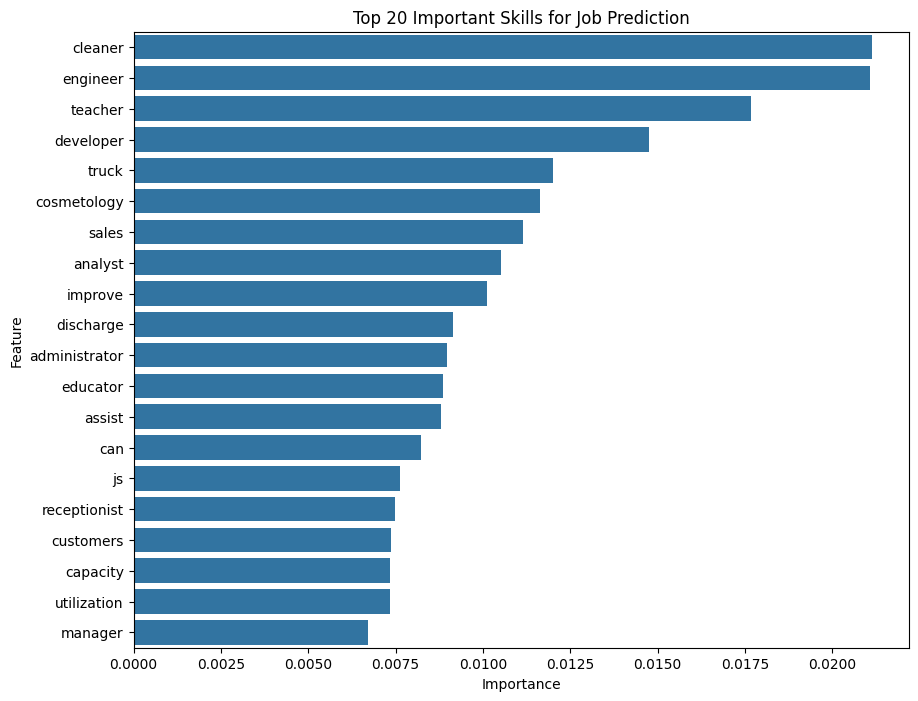

In [ ]:
# Get feature importance scores
importances = xgb_classifier.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [ ]:
# Plot top 20 important skills
plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Important Skills for Job Prediction')
plt.show()

In [ ]:
# 1. Flatten all skills into a single list
all_skills = df['core_skills_nlp_cleaned'].explode()

# 2. Count skill frequencies
skill_counts = Counter(all_skills)

# 3. Get Top 20 skills
top_skills = skill_counts.most_common(20)
skills, counts = zip(*top_skills)

# 4. Create Interactive Bar Plot
fig = px.bar(
    x=counts,
    y=skills,
    orientation='h',
    title='Top 20 Most In-Demand Skills',
    labels={'x': 'Frequency', 'y': 'Skill'},
    color=counts,
    color_continuous_scale='Blues'
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},  # Highest skill on top
    template='plotly_white',
    height=600,
    width=900
)

fig.show()

In [ ]:
# 1. Count job postings by city
city_counts = df['city'].value_counts().dropna().head(20)  # Only top 20 cities

# 2. Create Interactive Bar Plot
fig = px.bar(
    x=city_counts.values,
    y=city_counts.index,
    orientation='h',
    title='Top 20 Cities by Number of Job Postings',
    labels={'x': 'Number of Jobs', 'y': 'City'},
    color=city_counts.values,
    color_continuous_scale='Purples'
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    template='plotly_white',
    height=600,
    width=900
)

fig.show()

In [ ]:
# 1. Make sure salary is numeric
df['salary_cleaned'] = pd.to_numeric(df['salary_cleaned'], errors='coerce')

# 2. Drop missing salaries and career levels
salary_df = df.dropna(subset=['salary_cleaned', 'career_level'])

# 3. Create Interactive Box Plot
fig = px.box(
    salary_df,
    x='career_level',
    y='salary_cleaned',
    title='Salary Distribution by Career Level (Fixed & Clean)',
    labels={'career_level': 'Career Level', 'salary_cleaned': 'Salary (USD)'},
    color='career_level',
    color_discrete_sequence=px.colors.qualitative.Set2,
    points='all'  # Show individual salary outliers
)

fig.update_layout(
    template='plotly_white',
    xaxis_tickangle=-45,
    height=600,
    width=1000
)

fig.show()

In [ ]:
# 1. Group job categories
category_counts = df['job_category'].value_counts().reset_index()
category_counts.columns = ['job_category', 'count']

# 2. Separate 'Other' from rest
others_count = category_counts[category_counts['job_category'] == 'Other']['count'].sum()
filtered_categories = category_counts[category_counts['job_category'] != 'Other']

# 3. Create Pie Chart (excluding 'Other')
fig = px.pie(
    filtered_categories,
    values='count',
    names='job_category',
    title='Job Category Distribution (Excluding \"Other\")',
    color_discrete_sequence=px.colors.qualitative.Pastel1,
    hole=0.3  # Donut chart style
)

fig.update_traces(textinfo='percent+label')  # Show both % and label

fig.update_layout(
    template='plotly_white',
    height=600,
    width=800,
    annotations=[dict(
        text=f"Others ({round(others_count / category_counts['count'].sum() * 100, 1)}%)",
        x=0.5, y=-0.1, showarrow=False,
        font=dict(size=14)
    )]
)

fig.show()